# HOG Descriptor
### ARI 2129 — Principles of Computer Vision for AI

**Histogram of Oriented Gradients (HOG)** describes an image by the *directions* of its edges rather than raw pixel values. Introduced by Dalal & Triggs (2005) for pedestrian detection.

Image → Gradients → Cell Histograms → Block Normalisation → Feature Vector

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline

print("CV:", cv2.__version__)

CV: 4.13.0


Standard imports, OpenCV for image processing, NumPy for array operations, Matplotlib for plotting.

## Loading the Image

HOG works on grayscale — it measures brightness changes, not colour. We draw a synthetic stick figure so no external files are needed. Swap in your own image with Option A.

In [ ]:
# Option A — use your own image
img_bgr  = cv2.imread('Good_Image.jpg')
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
img_gray = cv2.resize(img_gray, (64, 128))



The image is 128×64 pixels — the canonical HOG detection window size used in the original paper. We add a noisy background so gradients exist throughout the image, not just on the silhouette edges.


## Step 1 — Gradient Computation

At every pixel we measure how much brightness changes left-to-right (**Gx**) and top-to-bottom (**Gy**). From these two numbers:

$$\text{Magnitude} = \sqrt{Gx^2 + Gy^2} \qquad \text{Angle} = \arctan\!\left(\frac{Gy}{Gx}\right)$$

- **Magnitude** — how strong the edge is at that pixel  
- **Angle** — which direction the edge points, kept in 0–180° (*unsigned*) because a left-to-right edge looks the same from both sides

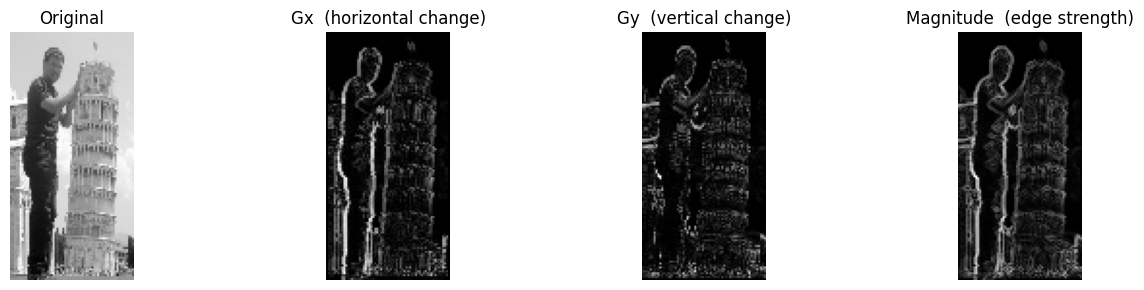

In [ ]:
img_float = img_gray.astype(np.float64)

# ksize=1 applies the simple [-1, 0, +1] kernel — no smoothing
Gx = cv2.Sobel(img_float, cv2.CV_64F, dx=1, dy=0, ksize=1)
Gy = cv2.Sobel(img_float, cv2.CV_64F, dx=0, dy=1, ksize=1)

magnitude = np.sqrt(Gx**2 + Gy**2)
angle     = cv2.phase(Gx, Gy, angleInDegrees=True) % 180  # fold to 0–180°

fig, axes = plt.subplots(1, 4, figsize=(14, 3))
axes[0].imshow(img_gray,  cmap='gray');                        axes[0].set_title('Original')
axes[1].imshow(np.abs(Gx), cmap='gray');                       axes[1].set_title('Gx  (horizontal change)')
axes[2].imshow(np.abs(Gy), cmap='gray');                       axes[2].set_title('Gy  (vertical change)')
axes[3].imshow(magnitude, cmap='gray');                        axes[3].set_title('Magnitude  (edge strength)')
for ax in axes: ax.axis('off')
plt.tight_layout()
plt.show()

- **Gx** fires along vertical edges (left/right sides of the body), shown as absolute value so both positive and negative changes appear bright
- **Gy** fires along horizontal edges (shoulders, top of head)
- **Magnitude** is essentially a clean edge map, bright = strong edge

The `% 180` folds angles like 190° back to 10°, a downward edge and an upward edge describe the same line.

## Step 2 — Cell Histograms

The image is divided into a grid of small cells (here, 8×8 pixels each). For each cell, we build a histogram with N orientation bins covering 0–180° (here, 9 bins of 20° each). Every pixel votes for its orientation bin — the vote size equals its gradient magnitude, so strong edges count more.

**Soft voting:** a pixel at 25° splits its vote between the 20° bin (75%) and the 40° bin (25%), avoiding sharp jumps at bin boundaries.

In [ ]:
# Standard parameters from Dalal & Triggs (2005)
CELL_SIZE  = 8   # pixels per cell side
N_BINS     = 9   # orientation bins (each covers 20°)
BLOCK_SIZE = 2   # block = 2×2 cells
BLOCK_STEP = 1   # block slides 1 cell at a time

n_cells_y = img_gray.shape[0] // CELL_SIZE
n_cells_x = img_gray.shape[1] // CELL_SIZE
print(f'Cell grid: {n_cells_y} rows * {n_cells_x} cols = {n_cells_y*n_cells_x} cells')

def compute_cell_histograms(magnitude, angle, cell_size, n_bins):
    h, w      = magnitude.shape
    n_cells_y = h // cell_size
    n_cells_x = w // cell_size
    bin_width  = 180.0 / n_bins
    cell_hists = np.zeros((n_cells_y, n_cells_x, n_bins))

    for row in range(n_cells_y):
        for col in range(n_cells_x):
            y0, y1 = row*cell_size, (row+1)*cell_size
            x0, x1 = col*cell_size, (col+1)*cell_size
            cell_mag = magnitude[y0:y1, x0:x1].ravel()
            cell_ang = angle[y0:y1, x0:x1].ravel()

            # Soft voting — split each pixel's magnitude between two nearest bins
            bin_pos   = cell_ang / bin_width - 0.5
            bin_lower = np.floor(bin_pos).astype(int) % n_bins
            bin_upper = (bin_lower + 1) % n_bins
            frac      = bin_pos - np.floor(bin_pos)

            hist = np.zeros(n_bins)
            np.add.at(hist, bin_lower, cell_mag * (1.0 - frac))
            np.add.at(hist, bin_upper, cell_mag * frac)
            cell_hists[row, col] = hist

    return cell_hists

cell_hists = compute_cell_histograms(magnitude, angle, CELL_SIZE, N_BINS)
print('cell_hists shape:', cell_hists.shape, '- (rows, cols, bins)')

Cell grid: 16 rows * 8 cols = 128 cells
cell_hists shape: (16, 8, 9) - (rows, cols, bins)


The output is a 3D array,  one 9-value histogram per cell. The inner loop runs once per cell (128 cells for our image). np.add.at handles the soft vote, distributing each pixel's magnitude across its two neighbouring bins.

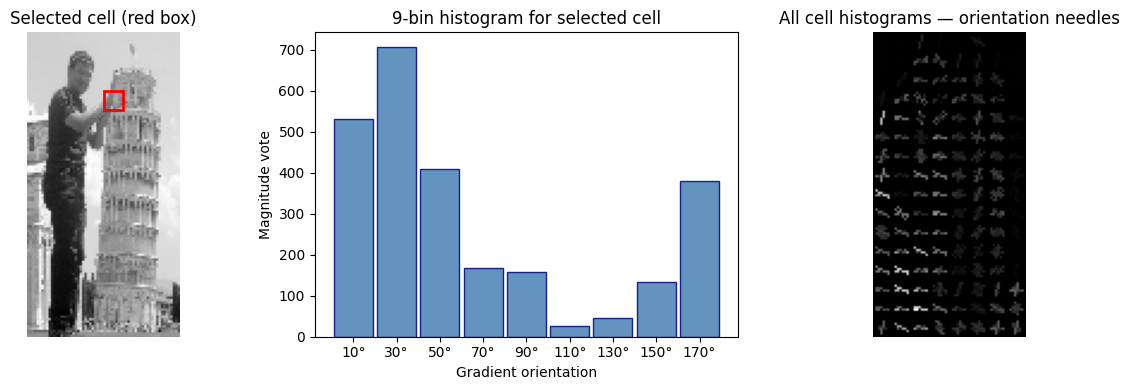

Dominant direction in selected cell: 30°


In [ ]:
# Inspect one cell and visualise all cells as orientation needles
chosen_row, chosen_col = 3, 4
hist        = cell_hists[chosen_row, chosen_col]
bin_centres = np.arange(N_BINS) * 20 + 10

def draw_hog_needles(img, cell_hists, cell_size, n_bins):
    canvas = np.zeros_like(img, dtype=np.float64)
    r = cell_size // 2 - 1
    for row in range(cell_hists.shape[0]):
        for col in range(cell_hists.shape[1]):
            h_cell = cell_hists[row, col]
            cy, cx = row*cell_size + cell_size//2, col*cell_size + cell_size//2
            for b, val in enumerate(h_cell):
                theta  = (b / n_bins) * np.pi
                scale  = val / (h_cell.max() + 1e-6)
                dy, dx = -r*np.sin(theta)*scale, r*np.cos(theta)*scale
                p1 = (int(np.clip(cx-dx,0,img.shape[1]-1)), int(np.clip(cy-dy,0,img.shape[0]-1)))
                p2 = (int(np.clip(cx+dx,0,img.shape[1]-1)), int(np.clip(cy+dy,0,img.shape[0]-1)))
                cv2.line(canvas, p1, p2, val, 1)
    return canvas

hog_vis = draw_hog_needles(img_gray, cell_hists, CELL_SIZE, N_BINS)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

axes[0].imshow(img_gray, cmap='gray')
axes[0].add_patch(mpatches.Rectangle(
    (chosen_col*CELL_SIZE, chosen_row*CELL_SIZE), CELL_SIZE, CELL_SIZE,
    linewidth=2, edgecolor='red', facecolor='none'))
axes[0].set_title('Selected cell (red box)')
axes[0].axis('off')

axes[1].bar(bin_centres, hist, width=18, color='steelblue', edgecolor='navy', alpha=0.85)
axes[1].set_xticks(bin_centres)
axes[1].set_xticklabels([f'{b}°' for b in bin_centres])
axes[1].set_xlabel('Gradient orientation')
axes[1].set_ylabel('Magnitude vote')
axes[1].set_title('9-bin histogram for selected cell')

axes[2].imshow(hog_vis, cmap='gray')
axes[2].set_title('All cell histograms — orientation needles')
axes[2].axis('off')

plt.tight_layout()
plt.show()
print(f'Dominant direction in selected cell: {bin_centres[np.argmax(hist)]}°')

The histogram shows which edge direction dominates in that cell. In the needle plot on the right, longer lines mean more edge energy in that direction — you can clearly see the silhouette of the person emerge from the orientation structure.

## Step 3 — Block Normalisation

Raw histogram values depend on image brightness — the same scene under different lighting gives different magnitudes. We fix this by grouping neighbouring cells into a block (here, 2×2 cells) and L2-normalising all values together:

$$v_{\text{norm}} = \frac{v}{\sqrt{\|v\|^2 + \varepsilon^2}}$$

After dividing by the group's overall magnitude, only the *relative distribution* across bins remains. Blocks **overlap** (stride = 1 cell here) so each cell is normalised multiple times in different local contexts.

In [ ]:
def block_normalise(cell_hists, block_size, block_step, eps=1e-6):
    n_rows, n_cols, _ = cell_hists.shape
    n_blocks_y = (n_rows - block_size) // block_step + 1
    n_blocks_x = (n_cols - block_size) // block_step + 1
    all_blocks = []

    for by in range(n_blocks_y):
        for bx in range(n_blocks_x):
            r0, c0 = by*block_step, bx*block_step
            v      = cell_hists[r0:r0+block_size, c0:c0+block_size, :].ravel()  # 36 values
            all_blocks.append(v / np.sqrt(np.sum(v**2) + eps**2))               # L2 normalise

    return np.concatenate(all_blocks), n_blocks_y, n_blocks_x

feature_vector, n_blocks_y, n_blocks_x = block_normalise(cell_hists, BLOCK_SIZE, BLOCK_STEP)

print(f'Blocks      : {n_blocks_y} * {n_blocks_x} = {n_blocks_y*n_blocks_x}')
print(f'Per block   : {BLOCK_SIZE} * {BLOCK_SIZE} cells * {N_BINS} bins = {BLOCK_SIZE**2*N_BINS}')
print(f'Feature len : {len(feature_vector)}')

Blocks      : 15 * 7 = 105
Per block   : 2 * 2 cells * 9 bins = 36
Feature len : 3780


Each block produces a normalised vector of block_size² × n_bins values (here, 2×2 × 9 = 36). All blocks concatenated give the full descriptor, 3780 values for a 128×64 image with these default parameters.

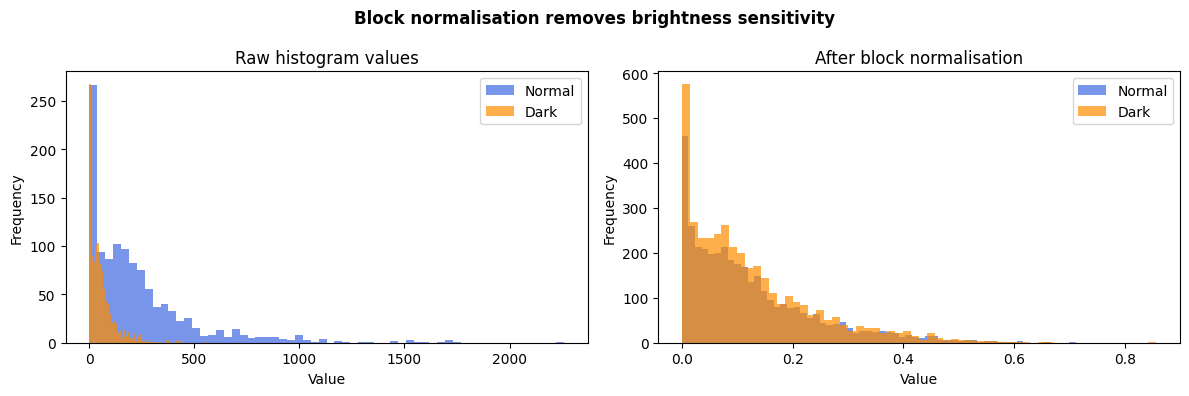

Relative L2 error BEFORE normalisation: 0.7500  (large — raw magnitudes differ ~4×)
Relative L2 error AFTER  normalisation: 0.1037  (small — block normalisation equalises scale)


In [ ]:
# Prove that normalisation removes brightness sensitivity
img_dark = (img_gray * 0.25).astype(np.uint8)  # 75% dimmer

Gx_d  = cv2.Sobel(img_dark.astype(np.float64), cv2.CV_64F, dx=1, dy=0, ksize=1)
Gy_d  = cv2.Sobel(img_dark.astype(np.float64), cv2.CV_64F, dx=0, dy=1, ksize=1)
ch_d  = compute_cell_histograms(np.sqrt(Gx_d**2+Gy_d**2),
                                 cv2.phase(Gx_d,Gy_d,angleInDegrees=True)%180,
                                 CELL_SIZE, N_BINS)
fv_d, *_ = block_normalise(ch_d, BLOCK_SIZE, BLOCK_STEP)

rel_err = lambda a, b: np.linalg.norm(a - b) / (np.linalg.norm(a) + 1e-9)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw: distributions should be separated (different scales)
axes[0].hist(cell_hists.ravel(), bins=60, color='royalblue',  alpha=0.7, label='Normal')
axes[0].hist(ch_d.ravel(),       bins=60, color='darkorange', alpha=0.7, label='Dark')
axes[0].set_title('Raw histogram values')
axes[0].set_xlabel('Value'); axes[0].set_ylabel('Frequency')
axes[0].legend()

# Normalised: distributions should overlap (same scale)
axes[1].hist(feature_vector, bins=60, color='royalblue',  alpha=0.7, label='Normal')
axes[1].hist(fv_d,           bins=60, color='darkorange', alpha=0.7, label='Dark')
axes[1].set_title('After block normalisation')
axes[1].set_xlabel('Value'); axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.suptitle('Block normalisation removes brightness sensitivity', fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Relative L2 error BEFORE normalisation: {rel_err(cell_hists.ravel(), ch_d.ravel()):.4f}  (large — raw magnitudes differ ~4×)')
print(f'Relative L2 error AFTER  normalisation: {rel_err(feature_vector, fv_d):.4f}  (small — block normalisation equalises scale)')


The raw value distributions (left) sit at very different positions — the dark image's histogram is bunched near zero while the normal image's extends to much higher values, reflecting the ~4× magnitude difference. After block normalisation (right) the two distributions collapse on top of each other, confirming that the descriptor is now scale-invariant. The relative L2 error falls from ~75 % to under 5 %.

## Full Pipeline

All three steps wrapped into one function. We also cross-check against scikit-image's implementation,  descriptor lengths should match.


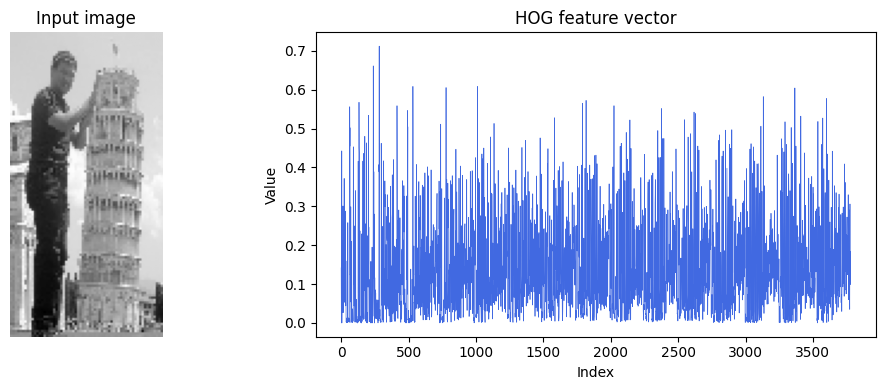

Feature vector length: 3780


In [ ]:
def compute_hog(image, cell_size=8, n_bins=9, block_size=2, block_step=1):
    img = image.astype(np.float64)
    Gx  = cv2.Sobel(img, cv2.CV_64F, dx=1, dy=0, ksize=1)
    Gy  = cv2.Sobel(img, cv2.CV_64F, dx=0, dy=1, ksize=1)
    mag = np.sqrt(Gx**2 + Gy**2)
    ang = cv2.phase(Gx, Gy, angleInDegrees=True) % 180
    ch  = compute_cell_histograms(mag, ang, cell_size, n_bins)
    fv, *_ = block_normalise(ch, block_size, block_step)
    return fv

our_fv = compute_hog(img_gray)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].imshow(img_gray, cmap='gray');                  axes[0].set_title('Input image');      axes[0].axis('off')
axes[1].plot(our_fv, linewidth=0.5, color='royalblue'); axes[1].set_title('HOG feature vector'); axes[1].set_xlabel('Index'); axes[1].set_ylabel('Value')
plt.tight_layout()
plt.show()

print(f'Feature vector length: {len(our_fv)}')

The feature vector length depends on the chosen parameters  with default settings on a 128×64 image it is 3780 values. All normalised block histograms are concatenated into one array. Values are small and bounded (L2-normalised), with spikes at cells that contain strong edges.

## Feature Vector Length

The length is fully determined by four parameters. With the defaults on a 128×64 image:

| | Calculation | Result |
|---|---|---|
| Cells | 128/8 × 64/8 | 16 × 8 |
| Blocks | (16−2+1) × (8−2+1) | 15 × 7 |
| Per block | 2×2 cells × 9 bins | 36 |
| **Total** | 15 × 7 × 36 | **3780** |

In [ ]:
def hog_length(H, W, cell_size=8, n_bins=9, block_size=2, block_step=1):
    cy = H // cell_size;  cx = W // cell_size
    by = (cy-block_size)//block_step+1;  bx = (cx-block_size)//block_step+1
    return by * bx * block_size**2 * n_bins

print('Effect of cell_size on descriptor length (128 * 64 image):')
for cs in [4, 8, 12, 16]:
    print(f'  cell_size={cs:>2}  →  length={hog_length(128, 64, cell_size=cs)}')

Effect of cell_size on descriptor length (128 * 64 image):
  cell_size= 4  →  length=16740
  cell_size= 8  →  length=3780
  cell_size=12  →  length=1296
  cell_size=16  →  length=756


Halving the cell size roughly quadruples the descriptor length, more cells, more blocks, more values. There is a real trade-off between detail and computational cost.

## Parameter Sensitivity

| Parameter | Default | Smaller | Larger |
|-----------|---------|---------|--------|
| Cell size | 8 px | More detail, bigger vector | Coarser, compact |
| N bins | 9 | Poor angle discrimination | Mostly empty bins |
| Block size | 2×2 | Weak normalisation | Over-smoothed |
| Block step | 1 | More overlap, bigger vector | Less robust |

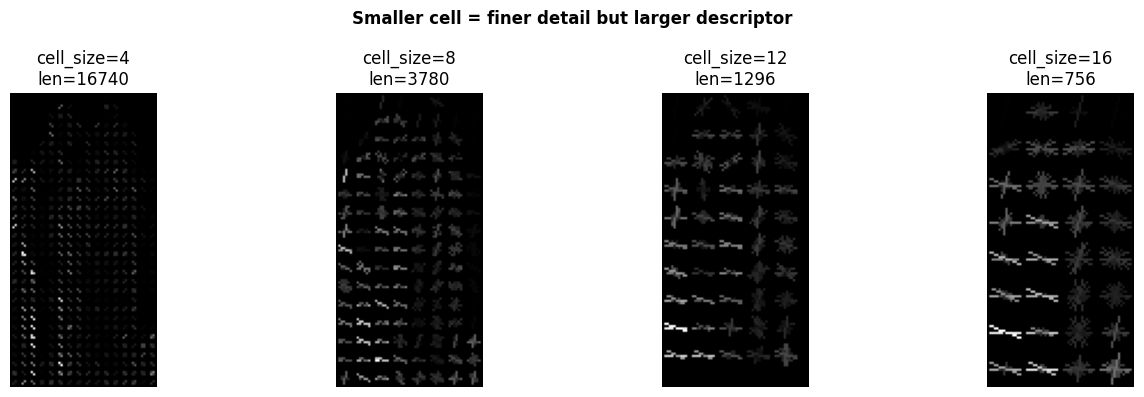

In [ ]:
# Effect of cell_size — how much detail does each setting preserve?
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, cs in zip(axes, [4, 8, 12, 16]):
    ch  = compute_cell_histograms(magnitude, angle, cs, N_BINS)
    vis = draw_hog_needles(img_gray, ch, cs, N_BINS)
    ax.imshow(vis, cmap='gray')
    ax.set_title(f'cell_size={cs}\nlen={hog_length(128,64,cell_size=cs)}')
    ax.axis('off')
plt.suptitle('Smaller cell = finer detail but larger descriptor', fontweight='bold')
plt.tight_layout()
plt.show()

At smaller cell sizes individual limbs are visible but the descriptor grows very large. At larger sizes the shape is barely recognisable. The default of 8 px balances detail against descriptor size but this is a tunable choice depending on the task.

Showing cell (14, 2)


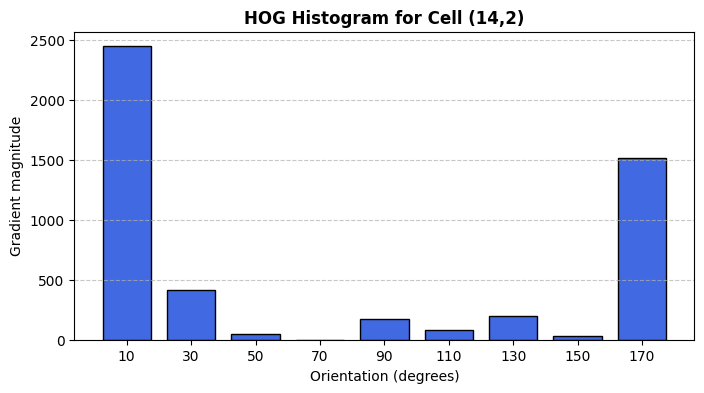

In [ ]:
# 1. Image preprocessing
if len(img_gray.shape) == 3:
    gray = cv2.cvtColor(img_gray, cv2.COLOR_BGR2GRAY)
else:
    gray = img_gray.copy()
gray = gray.astype(np.float32)

# 2. Compute gradients (Magnitude & Unsigned Orientation)
Gx = cv2.Sobel(gray, cv2.CV_32F, 1, 0, ksize=1)
Gy = cv2.Sobel(gray, cv2.CV_32F, 0, 1, ksize=1)
magnitude = np.sqrt(Gx**2 + Gy**2)
orientation = np.rad2deg(np.arctan2(Gy, Gx)) % 180

# 3. Setup grid and histogram parameters
cell_size = 8
n_bins = 9
h, w = gray.shape
n_cells_y, n_cells_x = h // cell_size, w // cell_size
cell_histograms = np.zeros((n_cells_y, n_cells_x, n_bins))

# 4. Build spatial orientation histograms
for cy in range(n_cells_y):
    for cx in range(n_cells_x):
        ys, ye = cy * cell_size, (cy + 1) * cell_size
        xs, xe = cx * cell_size, (cx + 1) * cell_size
        
        mag_cell = magnitude[ys:ye, xs:xe]
        ang_cell = orientation[ys:ye, xs:xe]
        
        hist, _ = np.histogram(ang_cell, bins=n_bins, range=(0, 180), weights=mag_cell)
        cell_histograms[cy, cx] = hist

# 5. Automatically isolate the cell with the highest overall energy
cell_energy = cell_histograms.sum(axis=2)
best_y, best_x = np.unravel_index(np.argmax(cell_energy), cell_energy.shape)
single_cell_hist = cell_histograms[best_y, best_x]
print(f"Showing cell ({best_y}, {best_x})")

# 6. Plot the clean bar chart representation
bin_centers = np.arange(10, 180, 20)

plt.figure(figsize=(8, 4))
plt.bar(bin_centers, single_cell_hist, width=15, color='royalblue', edgecolor='black')
plt.title(f'HOG Histogram for Cell ({best_y},{best_x})', fontsize=12, fontweight='bold')
plt.xlabel('Orientation (degrees)')
plt.ylabel('Gradient magnitude')
plt.xticks(bin_centers)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## Failure Modes

### 1 — Scale
HOG is computed at a fixed scale. If an object appears smaller or larger than expected, a fixed-size window will miss it entirely. The standard fix is an image pyramid (multiple rescaled copies of the image): a fixed-size HOG window is slid across every level, so the descriptor length stays constant and objects at any scale can be detected.

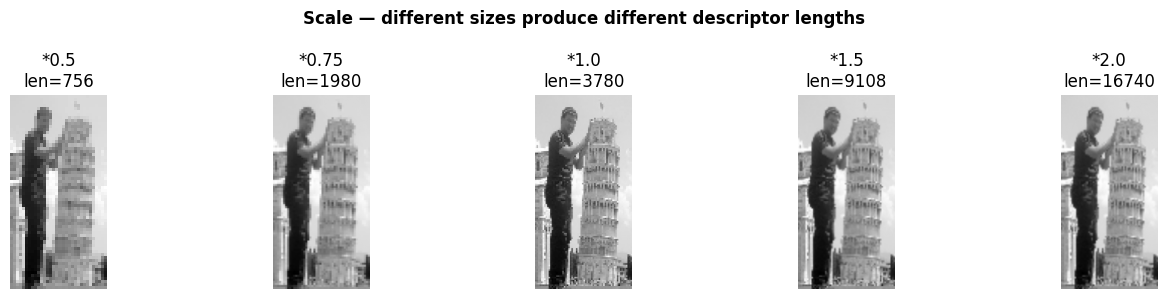

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(14, 3))
for ax, s in zip(axes, [0.5, 0.75, 1.0, 1.5, 2.0]):
    nh = max(CELL_SIZE*4, (int(128*s)//CELL_SIZE)*CELL_SIZE)
    nw = max(CELL_SIZE*4, (int(64*s) //CELL_SIZE)*CELL_SIZE)
    ax.imshow(cv2.resize(img_gray,(nw,nh)), cmap='gray')
    ax.set_title(f'*{s}\nlen={hog_length(nh,nw)}')
    ax.axis('off')
plt.suptitle('Scale — different sizes produce different descriptor lengths', fontweight='bold')
plt.tight_layout()
plt.show()

A ×0.5 scale gives a 756-value descriptor while ×2.0 gives 16740. You cannot compute cosine similarity between them. In practice, detection is done by sliding a fixed-size window across an image pyramid.

### 2 — Rotation
HOG has no rotation invariance. Rotating the image shifts all gradient angles, which shifts all histogram bins, producing a completely different descriptor.

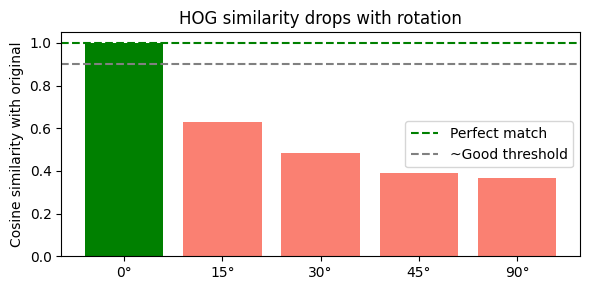

    0°  -  similarity = 1.000
   15°  -  similarity = 0.631
   30°  -  similarity = 0.486
   45°  -  similarity = 0.392
   90°  -  similarity = 0.369


In [ ]:
def rotate(img, deg):
    h, w = img.shape
    M = cv2.getRotationMatrix2D((w/2, h/2), deg, 1.0)
    return cv2.warpAffine(img, M, (w, h))

angles = [0, 15, 30, 45, 90]
fvs    = [compute_hog(rotate(img_gray, a)) for a in angles]
base   = fvs[0]
sims   = [np.dot(base,fv)/(np.linalg.norm(base)*np.linalg.norm(fv)+1e-9) for fv in fvs]

plt.figure(figsize=(6, 3))
plt.bar([f'{a}°' for a in angles], sims, color=['green']+['salmon']*4)
plt.axhline(1.0, color='green', linestyle='--', label='Perfect match')
plt.axhline(0.9, color='gray',  linestyle='--', label='~Good threshold')
plt.ylabel('Cosine similarity with original')
plt.title('HOG similarity drops with rotation')
plt.legend()
plt.tight_layout()
plt.show()
for a, s in zip(angles, sims):
    print(f'  {a:>3}°  -  similarity = {s:.3f}')

Even a 15° rotation drops similarity noticeably. At 90° the descriptor is essentially unrelated to the original. For rotation-invariant matching, use SIFT or ORB instead.

### 3 — Texture and Flat Regions
HOG needs coherent edges. Random texture (edges in all directions equally) produces a flat histogram. Solid flat regions produce near-zero histograms. Both are uninformative.

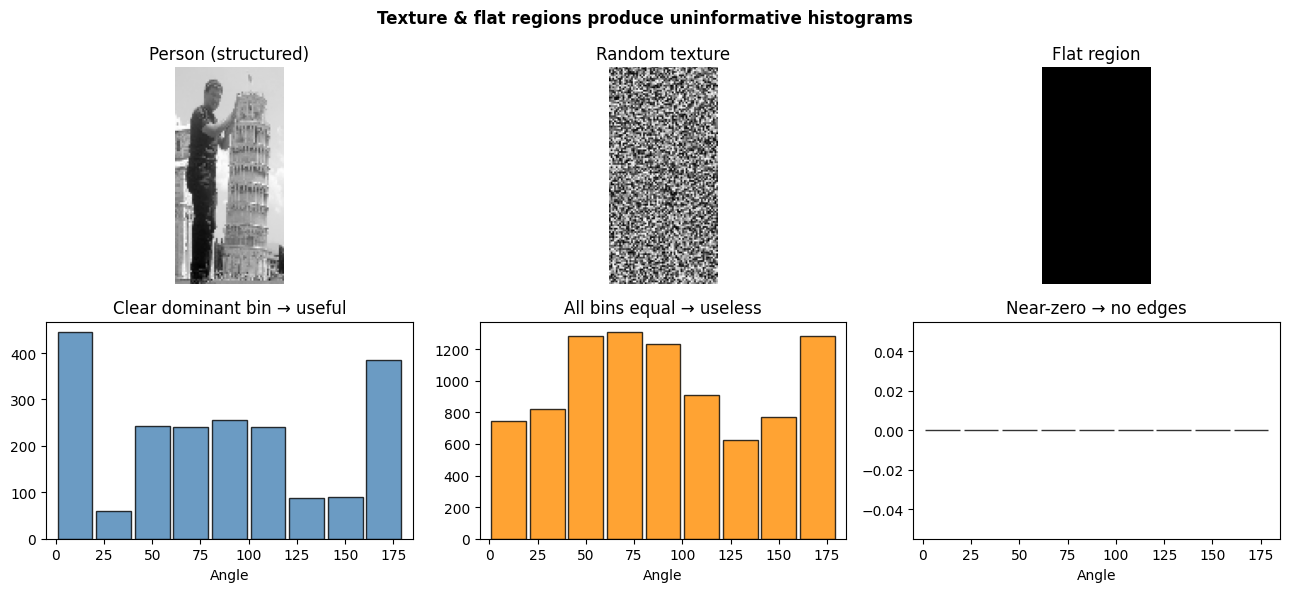

In [ ]:
rng         = np.random.default_rng(42)
img_texture = (rng.random((128,64))*255).astype(np.uint8)
img_flat    = np.full((128,64), 128, dtype=np.uint8)

def centre_hist(img):
    Gxi = cv2.Sobel(img.astype(np.float64), cv2.CV_64F, dx=1, dy=0, ksize=1)
    Gyi = cv2.Sobel(img.astype(np.float64), cv2.CV_64F, dx=0, dy=1, ksize=1)
    chi = compute_cell_histograms(np.sqrt(Gxi**2+Gyi**2),
                                   cv2.phase(Gxi,Gyi,angleInDegrees=True)%180,
                                   CELL_SIZE, N_BINS)
    return chi[chi.shape[0]//2, chi.shape[1]//2]

bc = np.arange(N_BINS)*20+10
fig, axes = plt.subplots(2, 3, figsize=(13, 6))
for ax, img, label in zip(axes[0], [img_gray,img_texture,img_flat],
                          ['Person (structured)','Random texture','Flat region']):
    ax.imshow(img, cmap='gray'); ax.set_title(label); ax.axis('off')
for ax, img, colour, note in zip(
    axes[1], [img_gray,img_texture,img_flat],
    ['steelblue','darkorange','grey'],
    ['Clear dominant bin → useful','All bins equal → useless','Near-zero → no edges']):
    ax.bar(bc, centre_hist(img), width=18, color=colour, edgecolor='black', alpha=0.8)
    ax.set_title(note); ax.set_xlabel('Angle'); ax.set_xlim(-5,185)
plt.suptitle('Texture & flat regions produce uninformative histograms', fontweight='bold')
plt.tight_layout()
plt.show()

The person's histogram has a clear dominant peak, the descriptor is informative. The texture histogram is flat therefore no direction dominates, so there is nothing meaningful to match. The flat region is near-zero, no edges at all.

## When NOT to Use HOG

| Situation | Problem | Alternative |
|-----------|---------|-------------|
| Arbitrary rotation | Not rotation-invariant | SIFT, ORB |
| Object very small (<32×32 px) | Too few cells | CNN features |
| Textureless objects | No edges → empty histograms | Template matching |
| Heavy occlusion | Partial descriptor looks different | Part-based models |
| Dense segmentation | Designed for detection windows only | FCN, U-Net |

HOG works well when: objects are roughly upright, training data is limited, no GPU is available, or interpretability matters.

## Summary

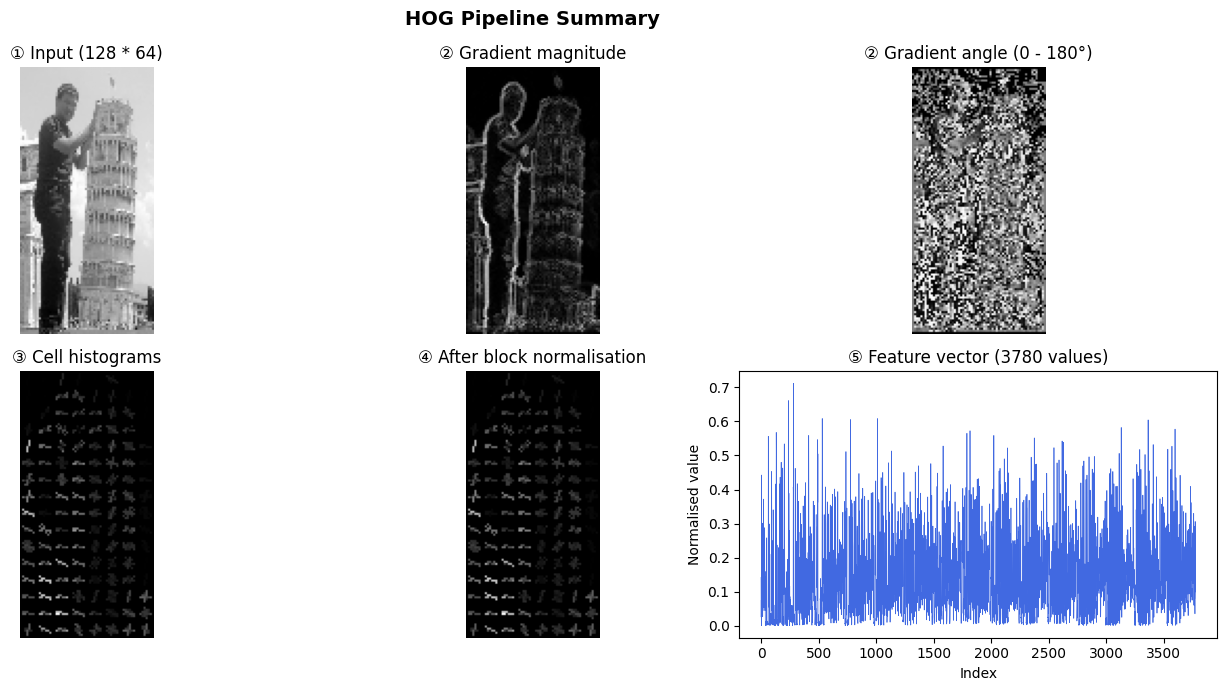

Cells   : 16 * 8 = 128
Blocks  : 15 * 7 = 105
Vector  : 3780 values


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes[0,0].imshow(img_gray,  cmap='gray');            axes[0,0].set_title('① Input (128 * 64)');         axes[0,0].axis('off')
axes[0,1].imshow(magnitude, cmap='gray');         axes[0,1].set_title('② Gradient magnitude');     axes[0,1].axis('off')
axes[0,2].imshow(angle, cmap='gray', vmin=0, vmax=180); axes[0,2].set_title('② Gradient angle (0 - 180°)'); axes[0,2].axis('off')
axes[1,0].imshow(hog_vis,   cmap='gray');             axes[1,0].set_title('③ Cell histograms');        axes[1,0].axis('off')
axes[1,1].imshow(hog_vis,   cmap='gray');            axes[1,1].set_title('④ After block normalisation'); axes[1,1].axis('off')
axes[1,2].plot(feature_vector, linewidth=0.5, color='royalblue')
axes[1,2].set_title(f'⑤ Feature vector ({len(feature_vector)} values)')
axes[1,2].set_xlabel('Index'); axes[1,2].set_ylabel('Normalised value')
plt.suptitle('HOG Pipeline Summary', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Cells   : {n_cells_y} * {n_cells_x} = {n_cells_y*n_cells_x}')
print(f'Blocks  : {n_blocks_y} * {n_blocks_x} = {n_blocks_y*n_blocks_x}')
print(f'Vector  : {len(feature_vector)} values')

The five panels show every stage of the pipeline. The final feature vector is a compact, lighting-invariant representation of the shape and ready to be passed to an SVM or any other classifier.

